# PARcast 
### ***Land Station Data***

In [61]:
# import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
# load the data
df = pd.read_csv('/Users/loriberberian/Desktop/bioSCape/PARcast/data_processing/data/raw/B_LPAR/B_LPAR_20260402_0002.CSV', 
                 parse_dates=['datetime'])

# quck look at the data
df.head(10)

,datetime,raw_counts,millivolts,ppfd_umol_m2_s
0,2026-04-02 12:44:09,8,0.0625,6.25
1,2026-04-02 12:44:10,8,0.0625,6.25
2,2026-04-02 12:44:11,8,0.0625,6.25
3,2026-04-02 12:44:12,8,0.0625,6.25
4,2026-04-02 12:44:13,8,0.0625,6.25
5,2026-04-02 12:44:14,8,0.0625,6.25
6,2026-04-02 12:44:15,8,0.0625,6.25
7,2026-04-02 12:44:16,8,0.0625,6.25
8,2026-04-02 12:44:17,8,0.0625,6.25
9,2026-04-02 12:44:18,8,0.0625,6.25


In [72]:
#summary statistics
df.describe()

,datetime,raw_counts,millivolts,ppfd_umol_m2_s
count,334,334.000000,334.000000,334.000000
mean,2026-04-02 12:46:57.574850304,2082.032934,16.265887,1626.588713
min,2026-04-02 12:44:09,0.000000,0.000000,0.000000
25%,2026-04-02 12:45:33.249999872,2441.000000,19.070300,1907.030000
50%,2026-04-02 12:46:57.500000,2445.500000,19.105500,1910.550000
75%,2026-04-02 12:48:21.750000128,2449.000000,19.132800,1913.280000
max,2026-04-02 12:49:46,2495.000000,19.492200,1949.220000
std,NaN,872.228120,6.814286,681.428611


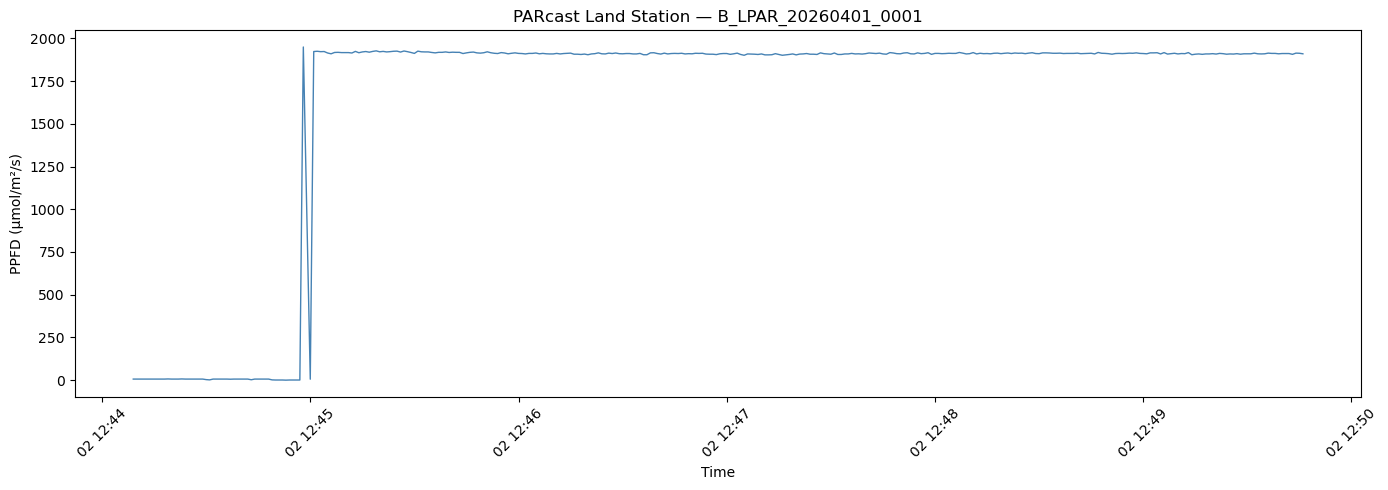

In [73]:
# Plot PPFD over time
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df['ppfd_umol_m2_s'], color='steelblue', linewidth=1)
plt.xlabel('Time')
plt.ylabel('PPFD (µmol/m²/s)')
plt.title('PARcast Land Station — B_LPAR_20260401_0001')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

12:45 took cap off
once we cleaned data plot looks better

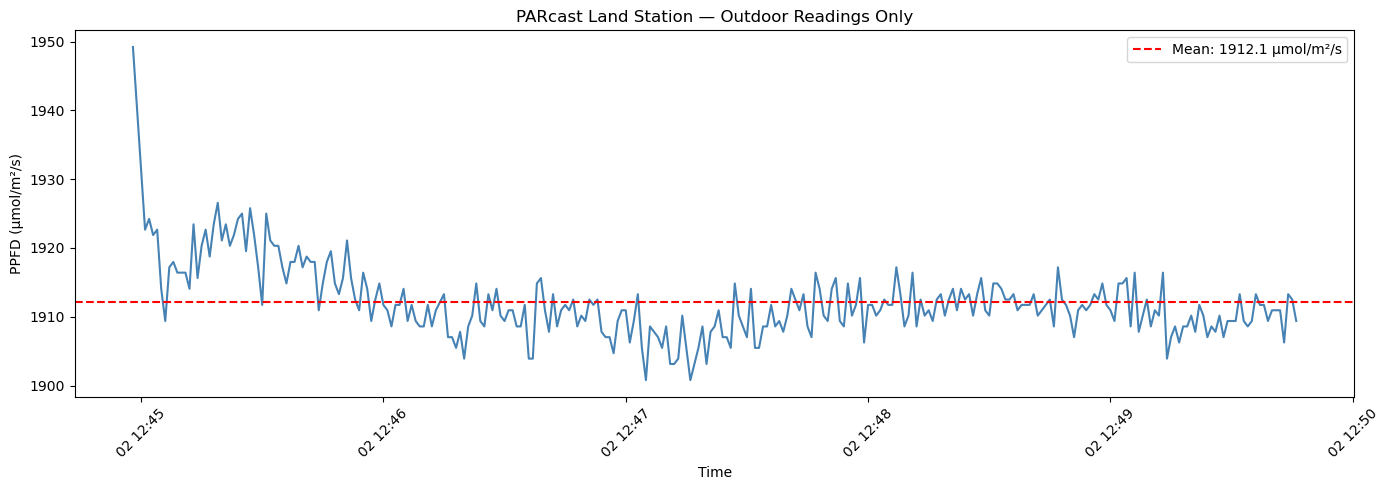

In [74]:
# filter to only show outdoor readings (PPFD > 10)
df_outdoor = df[df['ppfd_umol_m2_s'] > 10]

plt.figure(figsize=(14, 5))
plt.plot(df_outdoor['datetime'], df_outdoor['ppfd_umol_m2_s'], 
         color='steelblue', linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('PPFD (µmol/m²/s)')
plt.title('PARcast Land Station — Outdoor Readings Only')
plt.xticks(rotation=45)

# as mean line
mean_ppfd = df_outdoor['ppfd_umol_m2_s'].mean()
plt.axhline(y=mean_ppfd, color='red', linestyle='--', 
            label=f'Mean: {mean_ppfd:.1f} µmol/m²/s')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
# Summary statistics for outdoor readings only
print("=== PARcast Land Station Summary ===")
print(f"File: B_LPAR_20260401_0001.CSV")
print(f"Deployment start: {df['datetime'].min()}")
print(f"Deployment end:   {df['datetime'].max()}")
print(f"Total readings:   {len(df)}")
print(f"Outdoor readings: {len(df_outdoor)}")
print(f"Mean PPFD:        {df_outdoor['ppfd_umol_m2_s'].mean():.1f} µmol/m²/s")
print(f"Max PPFD:         {df_outdoor['ppfd_umol_m2_s'].max():.1f} µmol/m²/s")
print(f"Min PPFD:         {df_outdoor['ppfd_umol_m2_s'].min():.1f} µmol/m²/s")
print(f"Std deviation:    {df_outdoor['ppfd_umol_m2_s'].std():.1f} µmol/m²/s")

=== PARcast Land Station Summary ===
File: B_LPAR_20260401_0001.CSV
Deployment start: 2026-04-02 12:44:09
Deployment end:   2026-04-02 12:49:46
Total readings:   334
Outdoor readings: 284
Mean PPFD:        1912.1 µmol/m²/s
Max PPFD:         1949.2 µmol/m²/s
Min PPFD:         1900.8 µmol/m²/s
Std deviation:    5.2 µmol/m²/s
